In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
orders = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/kaggle_dados/olist_orders_dataset.csv')
order_items = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/kaggle_dados/olist_order_items_dataset.csv')
customers = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/kaggle_dados/olist_customers_dataset.csv')
products = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/kaggle_dados/olist_products_dataset.csv')
payments = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/kaggle_dados/olist_order_payments_dataset.csv')
reviews = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/kaggle_dados/olist_order_reviews_dataset.csv')
sellers = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/kaggle_dados/olist_sellers_dataset.csv')
category_translation = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/kaggle_dados/product_category_name_translation.csv')

Text(0.5, 0, 'Valor')

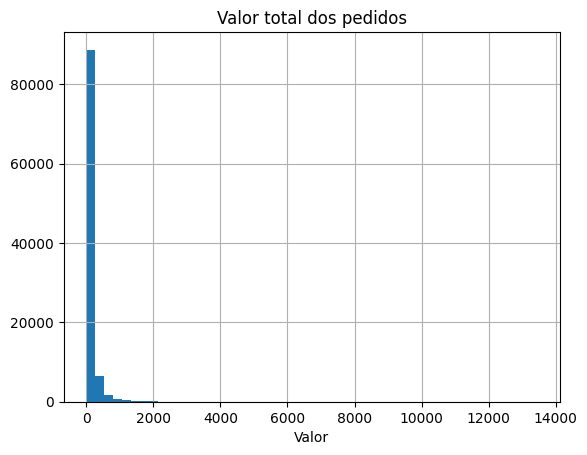

In [ ]:
order_items.groupby('order_id')['price'].sum().hist(bins=50)
plt.title('Valor total dos pedidos')
plt.xlabel('Valor')

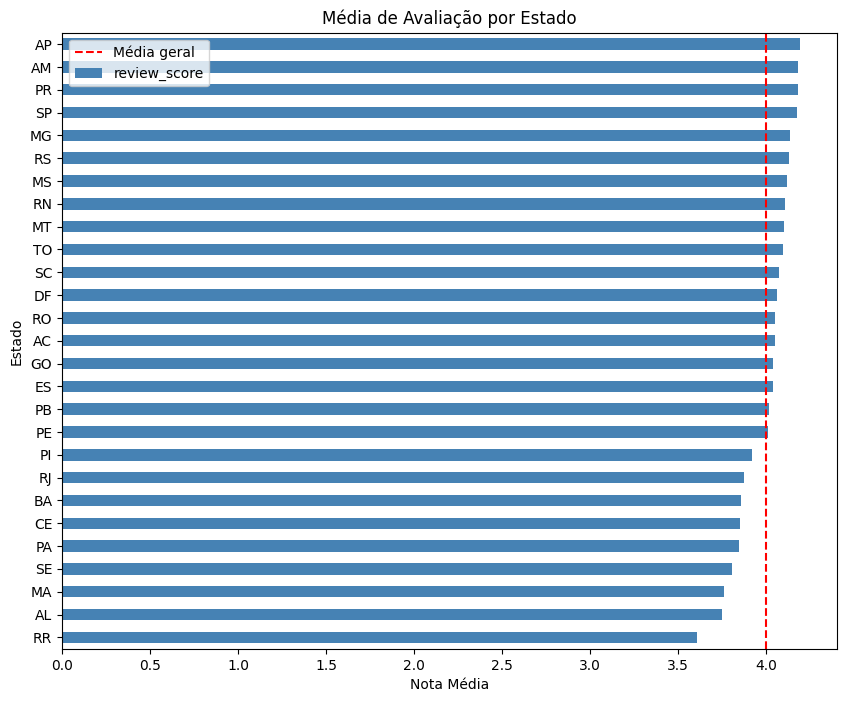

In [ ]:
df_media = reviews.merge(orders, on='order_id').merge(customers, on='customer_id')
media_estado = df_media.groupby('customer_state')['review_score'].mean().sort_values()

media_estado.plot(kind='barh', figsize=(10, 8), color='steelblue')
plt.title('Média de Avaliação por Estado')
plt.xlabel('Nota Média')
plt.ylabel('Estado')
plt.axvline(media_estado.mean(), color='red', linestyle='--', label='Média geral')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Correlação entre variáveis de produto')

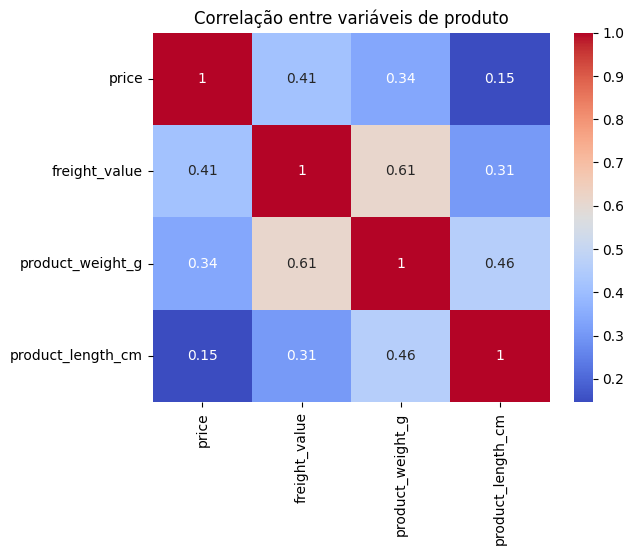

In [ ]:
cols = ['price', 'freight_value', 'product_weight_g', 'product_length_cm']
df_corr = order_items.merge(products, on='product_id')[cols]
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm')
plt.title('Correlação entre variáveis de produto')

Text(0.5, 1.0, 'Volume de Pedidos por Mês')

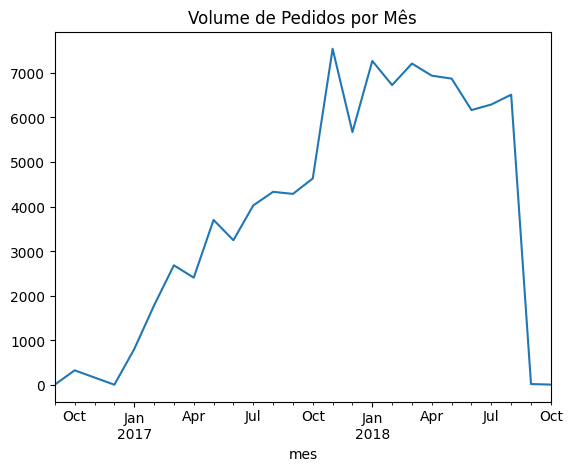

In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['mes'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders.groupby('mes')['order_id'].count().plot(kind='line')
plt.title('Volume de Pedidos por Mês')

Text(0.5, 1.0, 'Outliers no Valor do Frete')

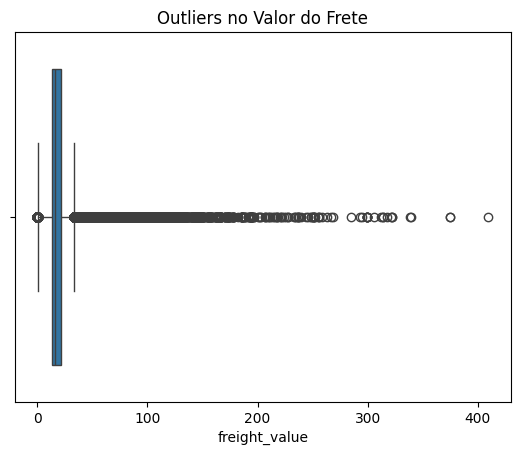

In [ ]:
sns.boxplot(x=order_items['freight_value'])
plt.title('Outliers no Valor do Frete')

In [ ]:
for nome, df in [('orders', orders), ('order_items', order_items),
                 ('products', products), ('reviews', reviews)]:
    print(f"\n{nome}:")
    print(df.isnull().sum()[df.isnull().sum() > 0])


orders:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

order_items:
Series([], dtype: int64)

products:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

reviews:
review_comment_title      87656
review_comment_message    58247
dtype: int64


In [ ]:
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('Sem comentário')
products['product_category_name'] = products['product_category_name'].fillna('sem_categoria')
orders_entregues = orders[orders['order_status'] == 'delivered'].copy()

In [ ]:
colunas_data = ['order_purchase_timestamp', 'order_approved_at',
                'order_delivered_customer_date', 'order_estimated_delivery_date']

for col in colunas_data:
    orders[col] = pd.to_datetime(orders[col])

In [ ]:
orders['dias_entrega'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

In [ ]:
orders['entregue_no_prazo'] = (
    orders['order_delivered_customer_date'] <= orders['order_estimated_delivery_date']
)

In [ ]:
orders.to_csv('orders_limpo.csv', index=False)
order_items.to_csv('order_items_limpo.csv', index=False)
reviews.to_csv('reviews_limpo.csv', index=False)
products.to_csv('products_limpo.csv', index=False)

In [ ]:
df = orders_entregues.copy()
df = df.merge(order_items, on='order_id')
df = df.merge(customers, on='customer_id')
df = df.merge(products, on='product_id')
df = df.merge(reviews[['order_id','review_score']], on='order_id', how='left')
df = df.merge(payments[['order_id','payment_type','payment_value']], on='order_id', how='left')
df = df.merge(category_translation, on='product_category_name', how='left')
df.to_csv('/content/drive/MyDrive/Colab Notebooks/kaggle_dados/olist_master.csv', index=False)

print(df.shape)
print(df.head())

(115723, 31)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
3    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
4    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2017-10-04 19:55:00     

In [ ]:
estados = {
    'SP': 'São Paulo', 'RJ': 'Rio de Janeiro', 'MG': 'Minas Gerais',
    'BA': 'Bahia', 'RS': 'Rio Grande do Sul', 'PR': 'Paraná',
    'SC': 'Santa Catarina', 'GO': 'Goiás', 'PE': 'Pernambuco',
    'CE': 'Ceará', 'PA': 'Pará', 'MT': 'Mato Grosso',
    'ES': 'Espírito Santo', 'MS': 'Mato Grosso do Sul', 'RO': 'Rondônia',
    'AM': 'Amazonas', 'DF': 'Distrito Federal', 'PB': 'Paraíba',
    'MA': 'Maranhão', 'RN': 'Rio Grande do Norte', 'AL': 'Alagoas',
    'PI': 'Piauí', 'SE': 'Sergipe', 'TO': 'Tocantins',
    'AC': 'Acre', 'AP': 'Amapá', 'RR': 'Roraima'
}

df['estado_nome'] = df['customer_state'].map(estados)

df.to_csv('/content/drive/MyDrive/Colab Notebooks/kaggle_dados/olist_master.csv', index=False)